In [107]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [143]:
spi = xr.open_dataset('spi_12mon.nc')['tp']

In [157]:
data = spi[200]
# Standardize the data (zero mean, unit variance)
data_standardized = (data - np.mean(data)) / np.std(data)
#print(data_standardized)

In [145]:
# Define the limits of the latitude range you want to focus on
lat_min = -75
lat_max = 75

# Mask the data to keep only the latitudes within the specified range
lat_mask = (data.latitude >= lat_min) & (data.latitude <= lat_max)
data_cropped = data[lat_mask, :]  # Keep only the rows corresponding to the selected latitudes
data_standardized = data_cropped 

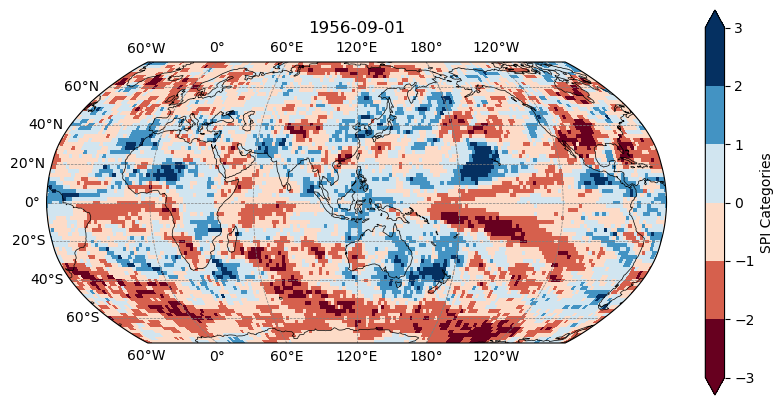

In [146]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import xarray as xr
import matplotlib.colors as mcolors

def plot_spi_map(data_values, latitude, longitude, title="SPI"):
    """
    Plots data on a map using Cartopy with Robinson projection centered at 120° longitude.
    The function formats the time if provided and includes it in the title.

    Parameters:
        data_values (2D array-like): The values to plot, with dimensions matching latitude and longitude.
        latitude (1D array-like): Array of latitude values.
        longitude (1D array-like): Array of longitude values.
        time (str or datetime, optional): Time to display in the title (formatted as "YYYY-MM-DD" if provided).
        title (str): The base title for the plot (default is "SPI").
    """
    # Create an xarray DataArray
    data_standardized = xr.DataArray(
        data_values,
        coords={"latitude": latitude, "longitude": longitude},
        dims=["latitude", "longitude"]
    )

    # Define SPI categories and colors
    levels = [-3, -2, -1, 0, 1, 2, 3]  # Discretized SPI categories
    cmap = plt.cm.RdBu
    norm = mcolors.BoundaryNorm(levels, cmap.N)
    
    # Create the plot with central longitude set to 120
    fig = plt.figure(figsize=(10, 5))
    ax = plt.axes(projection=ccrs.Robinson(central_longitude=120))

    # Add map features
    ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')

    # Plot data on the map with custom discrete colormap
    img = data_standardized.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),  # Assuming data is in Plate Carree projection
        cmap=cmap,
        norm=norm,
        cbar_kwargs={'label': 'SPI Categories', 'ticks': levels},  # Set ticks to match levels
    )

    # Set the title with the formatted time
    ax.set_title(title)

    # Show the plot
    plt.show()

# Example usage:
plot_spi_map(data_values=data_standardized, 
             latitude=data_standardized.latitude, 
             longitude=data_standardized.longitude, 
             title = pd.to_datetime(data_standardized.time.values).strftime('%Y-%m-%d')
             #title="Standardized Precipitation Index"
             )

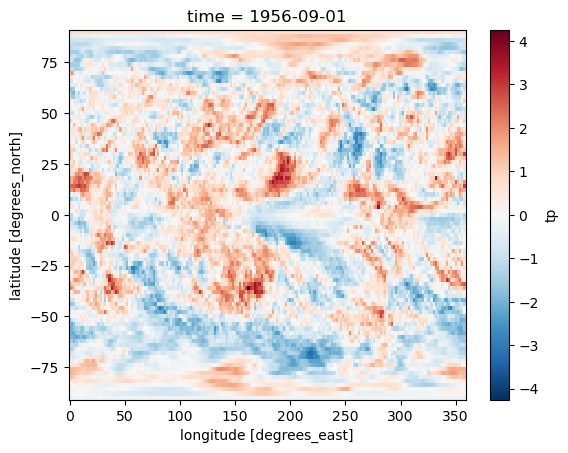

In [205]:
data_standardized.plot()
lats = data_standardized.latitude
weights = np.cos(np.radians(lats.values))[:, np.newaxis]  # Apply cos(lat) as a column vector
# Weight the data
dat2D = data_standardized * weights

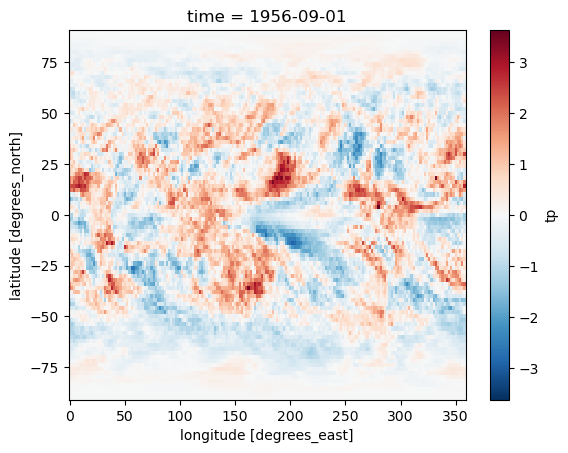

In [206]:
dat2D.plot()

In [207]:
# Apply 2D FFT
fft_data = np.fft.fft2(dat2D)


## Explain results

In [210]:
fft_data_shifted = np.fft.fftshift(fft_data)

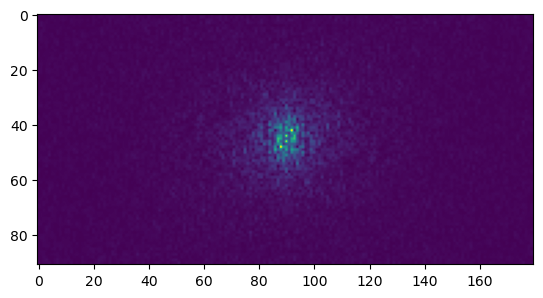

In [211]:
plt.imshow(magnitude)

In [212]:


# Compute the magnitude of the FFT
magnitude = np.abs(fft_data_shifted)

# Get the shape of the data (91, 180)
ny, nx = data_standardized.shape

# Create frequency arrays for both axes
freqs_y = np.fft.fftfreq(ny)
freqs_x = np.fft.fftfreq(nx)

# Meshgrid for frequency axes
freqs_y, freqs_x = np.meshgrid(freqs_x, freqs_y)

# Compute the radial frequency (distance from the center)
radial_freq = np.sqrt(freqs_y**2 + freqs_x**2)

# Normalize the radial frequencies to the maximum frequency
max_radial_freq = np.max(radial_freq)
radial_freq_normalized = radial_freq / max_radial_freq

# Define the number of bins for the radial frequency
num_bins = 20
freq_bins = np.linspace(0, 1, num_bins + 1)  # Normalized frequency bins

# Initialize energy array
energy = np.zeros(num_bins)

# Sum energy in each frequency bin
for i in range(num_bins):
    # Create a mask to select values within the current frequency bin
    mask = (radial_freq >= freq_bins[i]) & (radial_freq < freq_bins[i + 1])
    
    # Sum squared magnitudes within the mask
    energy[i] = np.sum(magnitude[mask]**2)  # Sum squared magnitudes for energy

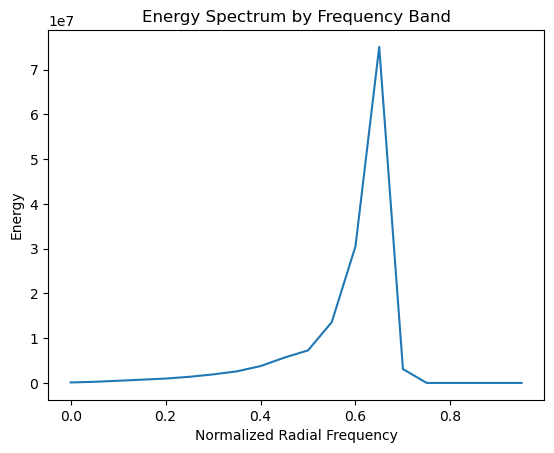

Cutoff Frequency: 0.6000000000000001
Cutoff Wavelength: 1.6666666666666665 (normalized)
Real Cutoff Wavelength: 184.99999999999997 km
Suggested New Grid Resolution: 184.99999999999997 km


In [213]:
# Plot the energy spectrum
plt.plot(freq_bins[:-1], energy)
plt.xlabel('Normalized Radial Frequency')
plt.ylabel('Energy')
plt.title('Energy Spectrum by Frequency Band')
plt.show()

# Step 1: Identify the cutoff frequency
# Let's assume we choose the frequency where the energy starts to drop off significantly
# We will look for the index where the energy starts to flatten
cutoff_index = np.argmax(np.diff(energy))  # Find the point where energy starts to decrease
cutoff_frequency = freq_bins[cutoff_index]  # The frequency corresponding to the cutoff
cutoff_wavelength = 1 / cutoff_frequency if cutoff_frequency > 0 else np.inf  # Wavelength corresponding to cutoff frequency

print(f"Cutoff Frequency: {cutoff_frequency}")
print(f"Cutoff Wavelength: {cutoff_wavelength} (normalized)")

# Step 2: Convert the cutoff wavelength to a real-world spatial scale
# The actual wavelength depends on the grid resolution of the data
# Assuming the data represents global lat/lon with a grid resolution of 1 degree (about 111 km)
real_cutoff_wavelength = cutoff_wavelength * 111  # Convert normalized wavelength to km (assuming 1° = 111 km)
print(f"Real Cutoff Wavelength: {real_cutoff_wavelength} km")

# Step 3: Choose a new grid resolution based on the cutoff wavelength
# For example, if the cutoff wavelength is 100 km, you might choose a grid spacing of 100 km or larger
new_grid_resolution = real_cutoff_wavelength  # You could adjust this to a coarser resolution, depending on your needs
print(f"Suggested New Grid Resolution: {new_grid_resolution} km")

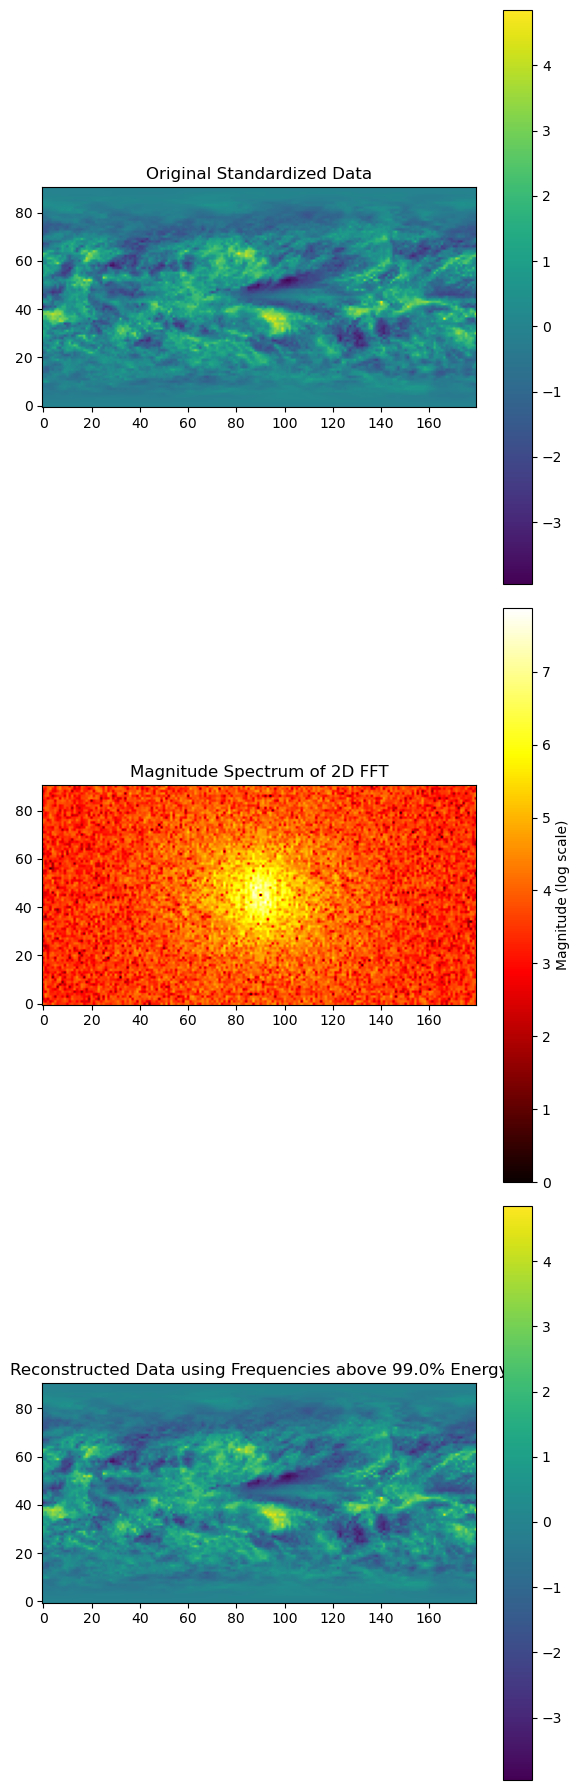

Cutoff Frequency: 0.2615667405526047


In [217]:
import numpy as np
import matplotlib.pyplot as plt

# Example climate data with shape (91, 180)
data = dat2D  # Replace with your actual climate data

# Standardize the data (zero mean, unit variance)
data_standardized = (data - np.mean(data)) / np.std(data)

# Apply 2D FFT
fft_data = np.fft.fft2(data_standardized)
fft_data_shifted = np.fft.fftshift(fft_data)  # Shift zero frequency to the center

# Compute the magnitude of the FFT
magnitude = np.abs(fft_data_shifted)

# Get the shape of the data (91, 180)
ny, nx = data.shape

# Create frequency arrays for both axes
freqs_y = np.fft.fftfreq(ny)
freqs_x = np.fft.fftfreq(nx)

# Meshgrid for frequency axes
freqs_y, freqs_x = np.meshgrid(freqs_x, freqs_y)

# Compute the radial frequency (distance from the center)
radial_freq = np.sqrt(freqs_y**2 + freqs_x**2)

# Normalize the radial frequencies to the maximum frequency
max_radial_freq = np.max(radial_freq)
radial_freq_normalized = radial_freq / max_radial_freq

# Step 1: Compute the energy spectrum
energy = np.abs(magnitude)**2  # Squared magnitude is a common way to represent energy

# Step 2: Compute cumulative energy and find the cutoff based on a threshold percentage
cumulative_energy = np.cumsum(energy)  # Cumulative sum of energy
total_energy = cumulative_energy[-1]  # Total energy (last value of cumulative sum)

# Define the threshold as a percentage of total energy
threshold_percentage = 0.99  # Keep the top 80% of energy
threshold_energy = total_energy * threshold_percentage

# Step 3: Find the cutoff frequency based on the threshold
cutoff_index = np.argmax(cumulative_energy >= threshold_energy)  # Index where cumulative energy exceeds threshold
cutoff_frequency = radial_freq.flatten()[cutoff_index]  # Corresponding cutoff frequency

# Step 4: Filter out low-energy frequencies
filtered_fft = np.zeros_like(fft_data_shifted, dtype=complex)

# Retain frequencies above the cutoff
filtered_fft[magnitude >= cutoff_frequency] = fft_data_shifted[magnitude >= cutoff_frequency]

# Step 5: Perform the inverse FFT to reconstruct the map
reconstructed_data = np.fft.ifft2(np.fft.ifftshift(filtered_fft))

# Take the real part of the inverse FFT result (since the FFT should produce real data)
reconstructed_data_real = np.real(reconstructed_data)

# Plot all three: original map, magnitude spectrum, and reconstructed map
plt.figure(figsize=(6, 18))

# Plot the original data (Standardized)
plt.subplot(3, 1, 1)
plt.imshow(data_standardized, cmap='viridis', origin='lower')
plt.colorbar()
plt.title('Original Standardized Data')

# Plot the magnitude spectrum (log scale for better visualization)
plt.subplot(3, 1, 2)
plt.imshow(np.log(magnitude + 1), cmap='hot', origin='lower')
plt.colorbar(label='Magnitude (log scale)')
plt.title('Magnitude Spectrum of 2D FFT')

# Plot the reconstructed data using the filtered frequencies
plt.subplot(3, 1, 3)
plt.imshow(reconstructed_data_real, cmap='viridis', origin='lower')
plt.colorbar()
plt.title(f'Reconstructed Data using Frequencies above {threshold_percentage*100}% Energy')

plt.tight_layout()
plt.show()

# Print the cutoff frequency value used
print(f"Cutoff Frequency: {cutoff_frequency}")


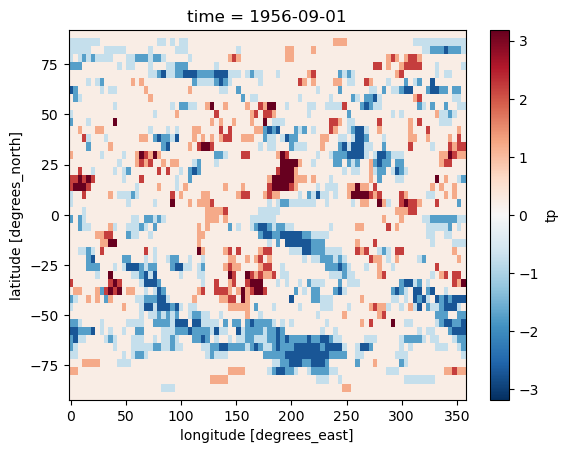

In [53]:
data_standardized.plot()

Peak Frequency: 0.19338864177427442
Peak Wavelength (normalized): 5.170934501764649
Peak Wavelength (real-world, km): 573.973729695876 km


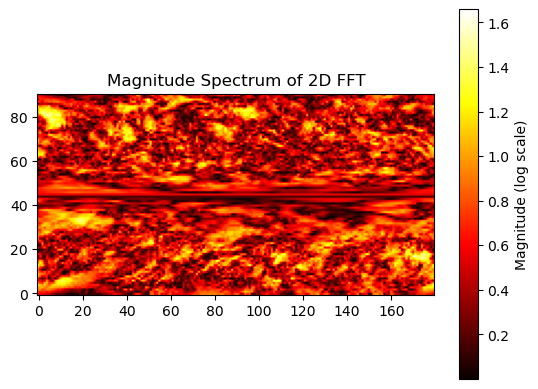

In [178]:
# Find the peak frequency (maximum magnitude)
peak_freq_index = np.unravel_index(np.argmax(magnitude), magnitude.shape)
peak_frequency = radial_freq[peak_freq_index]

# Translate the peak frequency to wavelength (1 / frequency)
peak_wavelength = 1 / peak_frequency if peak_frequency > 0 else np.inf

# Print the results
print(f"Peak Frequency: {peak_frequency}")
print(f"Peak Wavelength (normalized): {peak_wavelength}")

# If your data corresponds to a real-world grid, translate the peak wavelength
# Assuming a grid resolution of 1 degree (about 111 km)
real_peak_wavelength = peak_wavelength * 111  # Convert normalized to km

print(f"Peak Wavelength (real-world, km): {real_peak_wavelength} km")

# Plot the magnitude of the FFT
plt.imshow(np.log(magnitude + 1), cmap='hot', origin='lower')
plt.colorbar(label='Magnitude (log scale)')
plt.title('Magnitude Spectrum of 2D FFT')
plt.show()

In [76]:
data

<xarray.DataArray 'tp' (latitude: 91, longitude: 180)> Size: 131kB
array([[ 0.472923,  0.472923,  0.472923, ...,  0.472923,  0.472923,  0.472923],
       [-0.660544, -0.691161, -0.700974, ..., -0.520983, -0.58205 , -0.635503],
       [-1.186332, -1.118489, -1.077793, ..., -1.240203, -1.241951, -1.222128],
       ...,
       [-0.107122, -0.111854, -0.119433, ..., -0.071426, -0.086016, -0.115485],
       [-0.221931, -0.235943, -0.278064, ..., -0.163686, -0.173628, -0.219954],
       [-0.442476, -0.442476, -0.442476, ..., -0.442476, -0.442476, -0.442476]])
Coordinates:
  * longitude  (longitude) float32 720B 0.0 2.0 4.0 6.0 ... 354.0 356.0 358.0
  * latitude   (latitude) float32 364B 90.0 88.0 86.0 84.0 ... -86.0 -88.0 -90.0
    time       datetime64[ns] 8B 1956-09-01

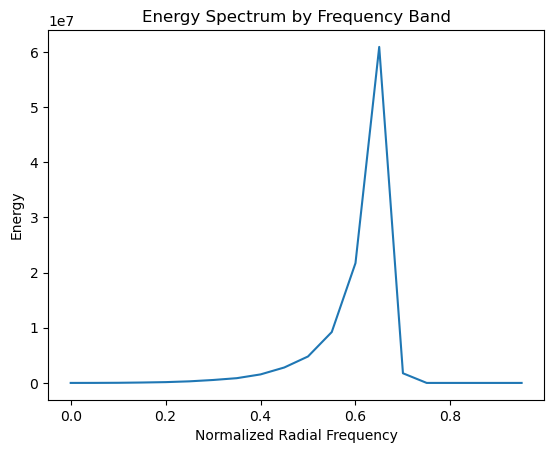

Cutoff Frequency: 0.6000000000000001
Cutoff Wavelength: 1.6666666666666665 (normalized)
Real Cutoff Wavelength: 184.99999999999997 km
Suggested New Grid Resolution: 184.99999999999997 km


In [77]:
import numpy as np
import matplotlib.pyplot as plt

data = spi[200]  # Example, replace with actual data

# Define the limits of the latitude range you want to focus on
lat_min = -60
lat_max = 60

# Mask the data to keep only the latitudes within the specified range
lat_mask = (data.latitude >= lat_min) & (data.latitude <= lat_max)
data_cropped = data[lat_mask, :]  # Keep only the rows corresponding to the selected latitudes


# Standardize the data (zero mean, unit variance)
data_standardized = (data_cropped - np.mean(data_cropped)) / np.std(data_cropped)

# Get the shape of the data (91, 180)
ny, nx = data_standardized.shape

# Create a grid of latitude (y) and longitude (x)
latitudes = np.linspace(-90, 90, ny)
longitudes = np.linspace(-180, 180, nx)

# Apply 2D FFT
fft_data = np.fft.fft2(data_standardized)
fft_data_shifted = np.fft.fftshift(fft_data)

# Compute the magnitude of the FFT
magnitude = np.abs(fft_data_shifted)

# Create frequency arrays for both axes
freqs_y = np.fft.fftfreq(ny)
freqs_x = np.fft.fftfreq(nx)

# Meshgrid for frequency axes
freqs_y, freqs_x = np.meshgrid(freqs_x, freqs_y)

# Compute the radial frequency (distance from the center)
radial_freq = np.sqrt(freqs_y**2 + freqs_x**2)

# Normalize the radial frequencies to the maximum frequency
max_radial_freq = np.max(radial_freq)
radial_freq_normalized = radial_freq / max_radial_freq

# Weight the data for latitude-longitude grid (compensating for decreasing longitude spacing near poles)
weighting = np.cos(np.radians(latitudes))  # Weighting based on cosine of latitude

# Initialize energy array
energy = np.zeros(20)  # We'll use 20 bins for the frequency spectrum
freq_bins = np.linspace(0, 1, 21)  # Normalized frequency bins

# Sum energy in each frequency bin
for i in range(20):
    # Create a mask to select values within the current frequency bin
    mask = (radial_freq >= freq_bins[i]) & (radial_freq < freq_bins[i + 1])
    
    # Sum squared magnitudes weighted by latitude spacing
    weighted_magnitude = magnitude * weighting[:, None]  # Apply the weighting to each latitude row
    energy[i] = np.sum(weighted_magnitude[mask]**2)  # Sum squared magnitudes for energy

# Plot the energy spectrum
plt.plot(freq_bins[:-1], energy)
plt.xlabel('Normalized Radial Frequency')
plt.ylabel('Energy')
plt.title('Energy Spectrum by Frequency Band')
plt.show()

# Step 1: Identify the cutoff frequency
# Let's assume we choose the frequency where the energy starts to drop off significantly
# We will look for the index where the energy starts to flatten
cutoff_index = np.argmax(np.diff(energy))  # Find the point where energy starts to decrease
cutoff_frequency = freq_bins[cutoff_index]  # The frequency corresponding to the cutoff
cutoff_wavelength = 1 / cutoff_frequency if cutoff_frequency > 0 else np.inf  # Wavelength corresponding to cutoff frequency

print(f"Cutoff Frequency: {cutoff_frequency}")
print(f"Cutoff Wavelength: {cutoff_wavelength} (normalized)")

# Step 2: Convert the cutoff wavelength to a real-world spatial scale
# The actual wavelength depends on the grid resolution of the data
# Assuming the data represents global lat/lon with a grid resolution of 1 degree (about 111 km)
real_cutoff_wavelength = cutoff_wavelength * 111  # Convert normalized wavelength to km (assuming 1° = 111 km)
print(f"Real Cutoff Wavelength: {real_cutoff_wavelength} km")

# Step 3: Choose a new grid resolution based on the cutoff wavelength
# For example, if the cutoff wavelength is 100 km, you might choose a grid spacing of 100 km or larger
new_grid_resolution = real_cutoff_wavelength  # You could adjust this to a coarser resolution, depending on your needs
print(f"Suggested New Grid Resolution: {new_grid_resolution} km")


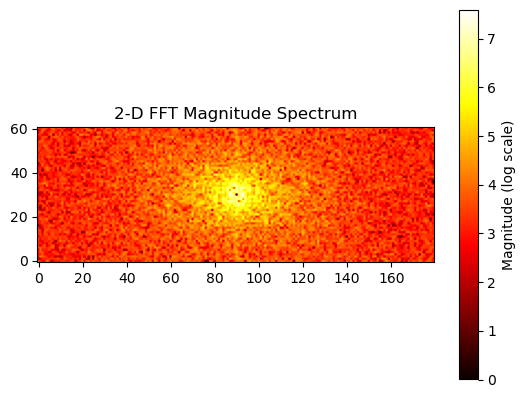

In [70]:
fft_data = np.fft.fft2(data_standardized)
fft_data_shifted = np.fft.fftshift(fft_data)
magnitude = np.abs(fft_data_shifted)
plt.imshow(np.log(magnitude + 1), cmap='hot', origin='lower')
plt.colorbar(label='Magnitude (log scale)')
plt.title('2-D FFT Magnitude Spectrum')
plt.show()

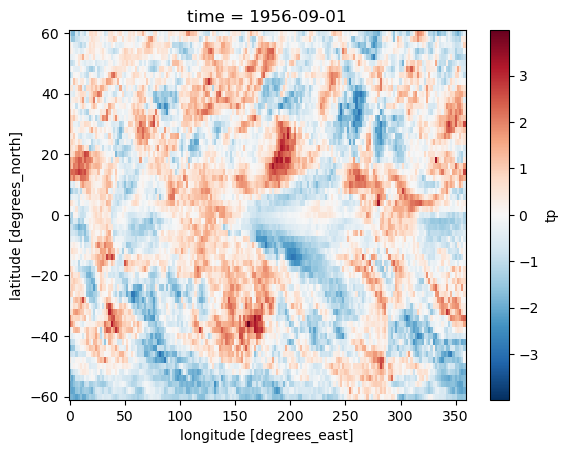

In [71]:
data_standardized.plot()

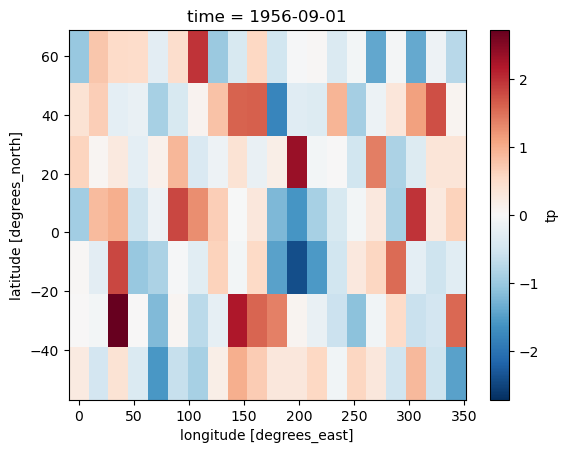

In [72]:
data_standardized[::9,::9].plot()

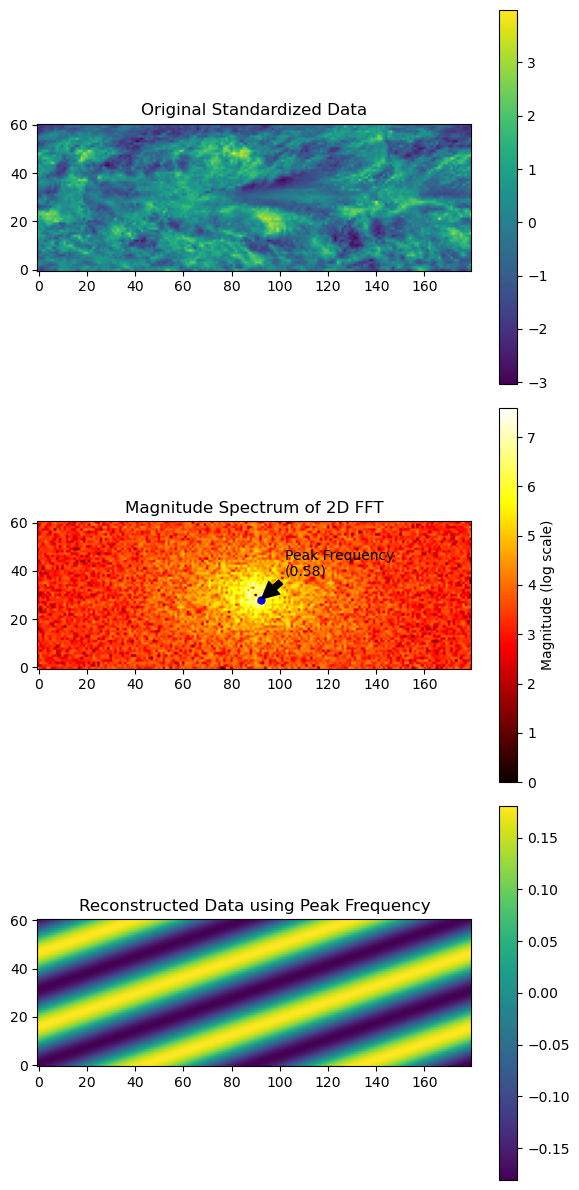

Peak Frequency: 0.577656387389623


In [83]:
# Apply 2D FFT
fft_data = np.fft.fft2(data_standardized)
fft_data_shifted = np.fft.fftshift(fft_data)  # Shift zero frequency to the center

# Compute the magnitude of the FFT
magnitude = np.abs(fft_data_shifted)

# Get the shape of the data (91, 180)
ny, nx = data.shape

# Create frequency arrays for both axes
freqs_y = np.fft.fftfreq(ny)
freqs_x = np.fft.fftfreq(nx)

# Meshgrid for frequency axes
freqs_y, freqs_x = np.meshgrid(freqs_x, freqs_y)

# Compute the radial frequency (distance from the center)
radial_freq = np.sqrt(freqs_y**2 + freqs_x**2)

# Normalize the radial frequencies to the maximum frequency
max_radial_freq = np.max(radial_freq)
radial_freq_normalized = radial_freq / max_radial_freq

# Find the peak frequency (index of the maximum magnitude)
peak_freq_index = np.unravel_index(np.argmax(magnitude), magnitude.shape)
peak_frequency = radial_freq[peak_freq_index]

# Filter the FFT to keep only the peak frequency and set others to zero
filtered_fft = np.zeros_like(fft_data_shifted, dtype=complex)

# Set the peak frequency (and its symmetric counterpart) in the filtered FFT
filtered_fft[peak_freq_index] = fft_data_shifted[peak_freq_index]

# Perform the inverse FFT to reconstruct the map
reconstructed_data = np.fft.ifft2(np.fft.ifftshift(filtered_fft))

# Take the real part of the inverse FFT result (since the FFT should produce real data)
reconstructed_data_real = np.real(reconstructed_data)

# Plot the original data, magnitude spectrum, and reconstructed data
plt.figure(figsize=(6, 12))

# Original Data
plt.subplot(3, 1, 1)
plt.imshow(data_standardized, cmap='viridis', origin='lower')
plt.colorbar()
plt.title('Original Standardized Data')

# Plot the magnitude spectrum (log scale for better visualization)
plt.subplot(3, 1, 2)
plt.imshow(np.log(magnitude + 1), cmap='hot', origin='lower')
plt.colorbar(label='Magnitude (log scale)')
plt.title('Magnitude Spectrum of 2D FFT')

# Mark the peak frequency on the spectrum plot
plt.plot(peak_freq_index[1], peak_freq_index[0], 'bo', markersize=5)  # Mark the peak frequency with a blue dot
plt.annotate(f'Peak Frequency\n({peak_frequency:.2f})', 
             xy=(peak_freq_index[1], peak_freq_index[0]), 
             xytext=(peak_freq_index[1] + 10, peak_freq_index[0] + 10),
             arrowprops=dict(facecolor='black', shrink=0.05))

# Reconstructed Data using Peak Frequency
plt.subplot(3, 1, 3)
plt.imshow(reconstructed_data_real, cmap='viridis', origin='lower')
plt.colorbar()
plt.title('Reconstructed Data using Peak Frequency')

plt.tight_layout()
plt.show()

# Print the results
print(f"Peak Frequency: {peak_frequency}")

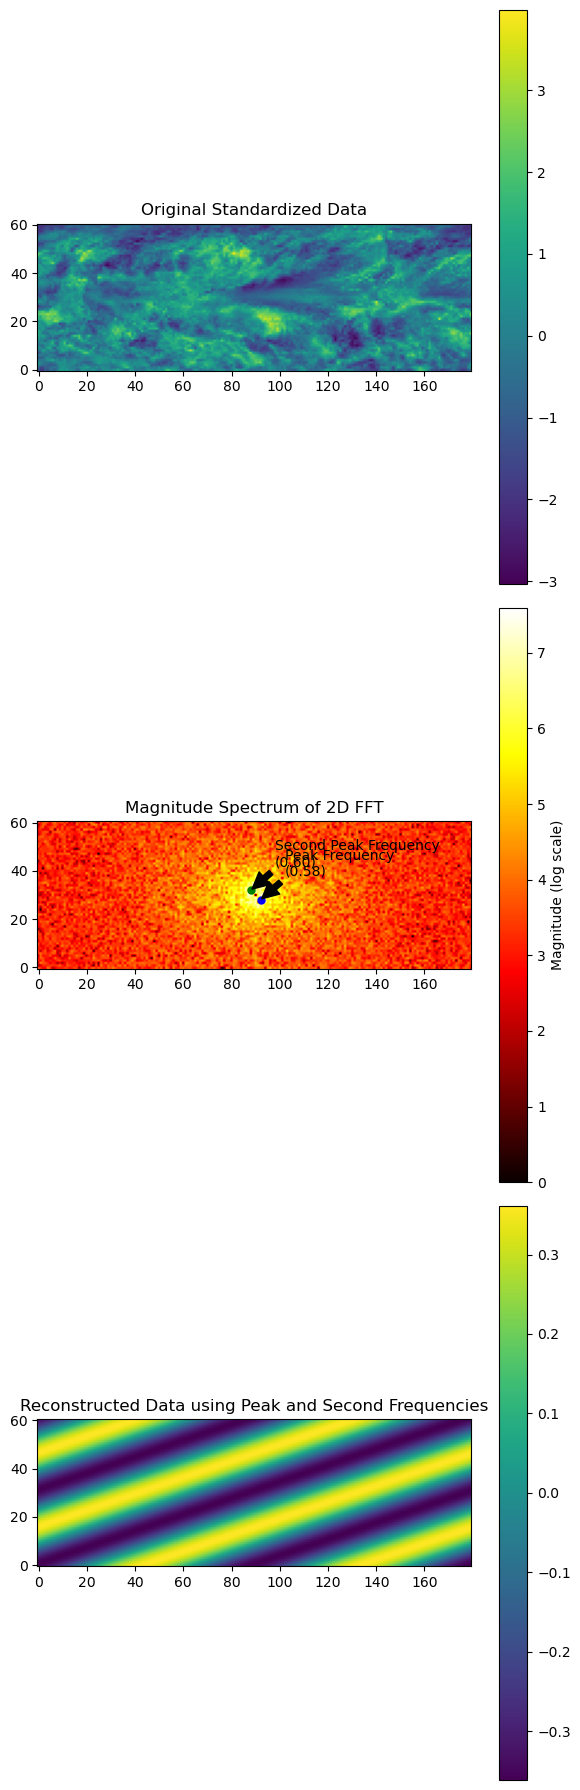

Peak Frequency: 0.58
Second Peak Frequency: 0.60


In [84]:
import numpy as np
import matplotlib.pyplot as plt


# Apply 2D FFT
fft_data = np.fft.fft2(data_standardized)
fft_data_shifted = np.fft.fftshift(fft_data)  # Shift zero frequency to the center

# Compute the magnitude of the FFT
magnitude = np.abs(fft_data_shifted)

# Get the shape of the data (91, 180)
ny, nx = data.shape

# Create frequency arrays for both axes
freqs_y = np.fft.fftfreq(ny)
freqs_x = np.fft.fftfreq(nx)

# Meshgrid for frequency axes
freqs_y, freqs_x = np.meshgrid(freqs_x, freqs_y)

# Compute the radial frequency (distance from the center)
radial_freq = np.sqrt(freqs_y**2 + freqs_x**2)

# Normalize the radial frequencies to the maximum frequency
max_radial_freq = np.max(radial_freq)
radial_freq_normalized = radial_freq / max_radial_freq

# Find the peak frequency (index of the maximum magnitude)
peak_freq_index = np.unravel_index(np.argmax(magnitude), magnitude.shape)

# Find the second highest frequency by setting the peak to zero and finding the next maximum
magnitude_copy = magnitude.copy()
magnitude_copy[peak_freq_index] = 0
second_peak_freq_index = np.unravel_index(np.argmax(magnitude_copy), magnitude_copy.shape)

# Filter the FFT to keep only the peak and second frequency and set others to zero
filtered_fft = np.zeros_like(fft_data_shifted, dtype=complex)

# Set the peak frequency and second frequency in the filtered FFT
filtered_fft[peak_freq_index] = fft_data_shifted[peak_freq_index]
filtered_fft[second_peak_freq_index] = fft_data_shifted[second_peak_freq_index]

# Perform the inverse FFT to reconstruct the map
reconstructed_data = np.fft.ifft2(np.fft.ifftshift(filtered_fft))

# Take the real part of the inverse FFT result (since the FFT should produce real data)
reconstructed_data_real = np.real(reconstructed_data)

# Plot all three: original map, magnitude spectrum, and reconstructed map
plt.figure(figsize=(6, 18))

# Plot the original data (Standardized)
plt.subplot(3, 1, 1)
plt.imshow(data_standardized, cmap='viridis', origin='lower')
plt.colorbar()
plt.title('Original Standardized Data')

# Plot the magnitude spectrum (log scale for better visualization)
plt.subplot(3, 1, 2)
plt.imshow(np.log(magnitude + 1), cmap='hot', origin='lower')
plt.colorbar(label='Magnitude (log scale)')
plt.title('Magnitude Spectrum of 2D FFT')

# Mark the peak and second peak frequencies on the spectrum plot
plt.plot(peak_freq_index[1], peak_freq_index[0], 'bo', markersize=5)  # Mark the peak frequency with a blue dot
plt.plot(second_peak_freq_index[1], second_peak_freq_index[0], 'go', markersize=5)  # Mark the second frequency with a green dot

# Annotate peak frequencies
plt.annotate(f'Peak Frequency\n({radial_freq[peak_freq_index]:.2f})', 
             xy=(peak_freq_index[1], peak_freq_index[0]), 
             xytext=(peak_freq_index[1] + 10, peak_freq_index[0] + 10),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.annotate(f'Second Peak Frequency\n({radial_freq[second_peak_freq_index]:.2f})', 
             xy=(second_peak_freq_index[1], second_peak_freq_index[0]), 
             xytext=(second_peak_freq_index[1] + 10, second_peak_freq_index[0] + 10),
             arrowprops=dict(facecolor='black', shrink=0.05))

# Plot the reconstructed data using only the peak and second frequencies
plt.subplot(3, 1, 3)
plt.imshow(reconstructed_data_real, cmap='viridis', origin='lower')
plt.colorbar()
plt.title('Reconstructed Data using Peak and Second Frequencies')

plt.tight_layout()
plt.show()

# Print the peak and second peak frequency values
print(f"Peak Frequency: {radial_freq[peak_freq_index]:.2f}")
print(f"Second Peak Frequency: {radial_freq[second_peak_freq_index]:.2f}")


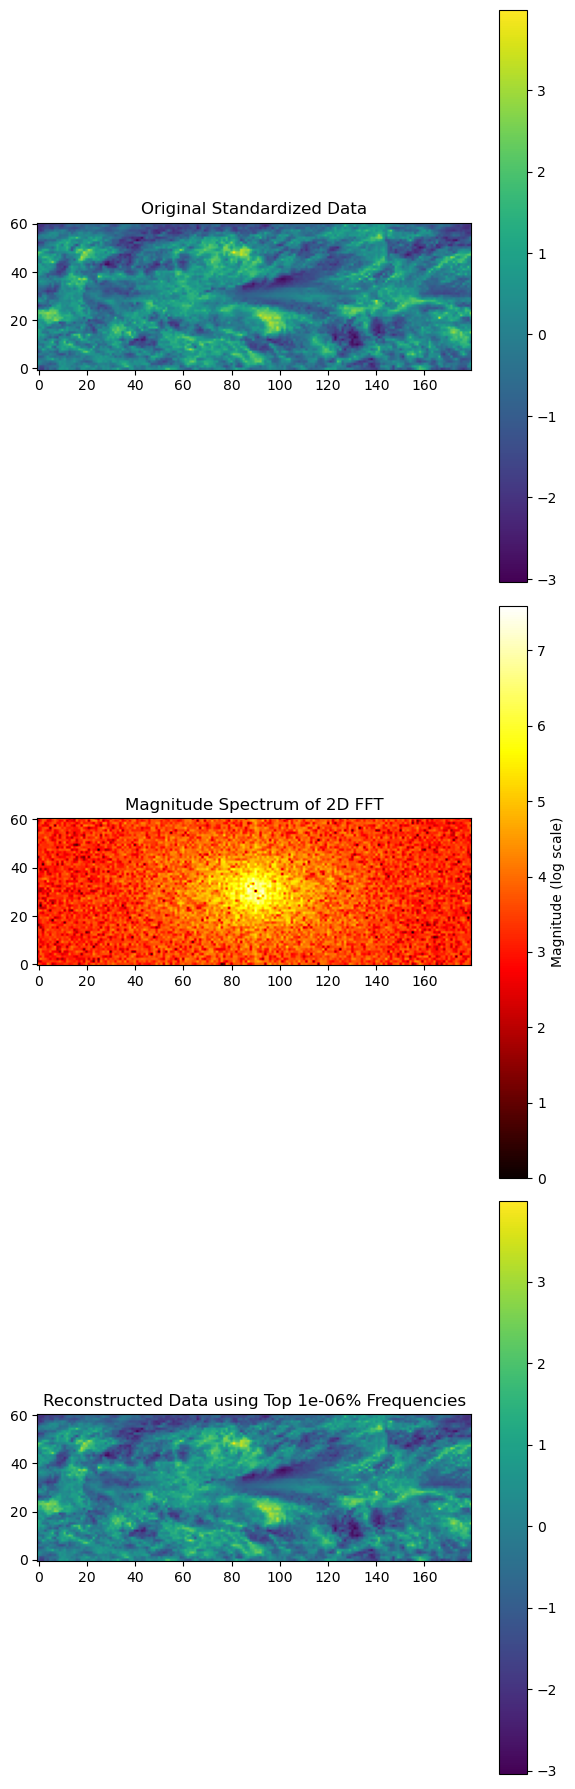

Threshold value (magnitude): 1.9846928821171586e-05


In [92]:

# Apply 2D FFT
fft_data = np.fft.fft2(data_standardized)
fft_data_shifted = np.fft.fftshift(fft_data)  # Shift zero frequency to the center

# Compute the magnitude of the FFT
magnitude = np.abs(fft_data_shifted)

# Get the shape of the data (91, 180)
ny, nx = data.shape

# Create frequency arrays for both axes
freqs_y = np.fft.fftfreq(ny)
freqs_x = np.fft.fftfreq(nx)

# Meshgrid for frequency axes
freqs_y, freqs_x = np.meshgrid(freqs_x, freqs_y)

# Compute the radial frequency (distance from the center)
radial_freq = np.sqrt(freqs_y**2 + freqs_x**2)

# Normalize the radial frequencies to the maximum frequency
max_radial_freq = np.max(radial_freq)
radial_freq_normalized = radial_freq / max_radial_freq

# Step 1: Set a threshold based on the magnitude spectrum
# Define the threshold as a percentage of the maximum magnitude
threshold_percentage = 1*10**(-8)  # For example, keep the top 5% of the frequencies

# Compute the threshold value
threshold_value = threshold_percentage * np.max(magnitude)

# Step 2: Filter the FFT to retain only frequencies above the threshold
filtered_fft = np.zeros_like(fft_data_shifted, dtype=complex)

# Retain frequencies with magnitude greater than the threshold
filtered_fft[magnitude >= threshold_value] = fft_data_shifted[magnitude >= threshold_value]

# Step 3: Perform the inverse FFT to reconstruct the map
reconstructed_data = np.fft.ifft2(np.fft.ifftshift(filtered_fft))

# Take the real part of the inverse FFT result (since the FFT should produce real data)
reconstructed_data_real = np.real(reconstructed_data)

# Plot all three: original map, magnitude spectrum, and reconstructed map
plt.figure(figsize=(6, 18))

# Plot the original data (Standardized)
plt.subplot(3, 1, 1)
plt.imshow(data_standardized, cmap='viridis', origin='lower')
plt.colorbar()
plt.title('Original Standardized Data')

# Plot the magnitude spectrum (log scale for better visualization)
plt.subplot(3, 1, 2)
plt.imshow(np.log(magnitude + 1), cmap='hot', origin='lower')
plt.colorbar(label='Magnitude (log scale)')
plt.title('Magnitude Spectrum of 2D FFT')

# Plot the reconstructed data using the filtered frequencies
plt.subplot(3, 1, 3)
plt.imshow(reconstructed_data_real, cmap='viridis', origin='lower')
plt.colorbar()
plt.title(f'Reconstructed Data using Top {threshold_percentage*100}% Frequencies')

plt.tight_layout()
plt.show()

# Print the threshold value used
print(f"Threshold value (magnitude): {threshold_value}")


(10979,)

In [5]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
from ipywidgets import interact
import numpy as np

# Assuming 'spi_categorical' is the xarray DataArray with dimensions ('time', 'latitude', 'longitude')
# and contains integer values representing categories:
# -3 = Extremely dry, -2 = Severely dry, -1 = Moderately dry, 0 = Near normal,
# 1 = Moderately wet, 2 = Severely wet, 3 = Extremely wet

# Define the color map for SPI categories
category_colors = {
    -3: "darkred",       # Extremely dry
    -2: "red",           # Severely dry
    -1: "salmon",        # Moderately dry
     0: "white",     # Near normal
     1: "lightblue",     # Moderately wet
     2: "blue",          # Severely wet
     3: "darkblue"       # Extremely wet
}

# Create a ListedColormap based on the category colors
cmap = ListedColormap([category_colors[i] for i in sorted(category_colors.keys())])
norm = plt.Normalize(vmin=-3, vmax=3)

# Function to plot a specific time slice
def plot_spi(time_index):
    # Select the data for the specific time index
    spi_categorical_2d = spi_categorical.isel(time=time_index)

    # Plot with Cartopy
    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_title(f"Categorized SPI at Time Index {time_index}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    
    # Plot the data
    img = ax.pcolormesh(
        spi_categorical_2d.longitude, spi_categorical_2d.latitude,
        spi_categorical_2d, cmap=cmap, norm=norm, transform=ccrs.PlateCarree()
    )
    
    # Add coastlines and features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="none")
    
    # Add colorbar
    cbar = plt.colorbar(img, ax=ax, orientation="vertical", pad=0.02, ticks=np.arange(-3, 4))
    cbar.set_label("SPI Categories")
    cbar.set_ticks(sorted(category_colors.keys()))
    cbar.set_ticklabels([
        "Extremely dry", "Severely dry", "Moderately dry", "Near normal", 
        "Moderately wet", "Severely wet", "Extremely wet"
    ])
    
    plt.show()

# Interactive widget for selecting the time index
interact(plot_spi, time_index=(0, spi_categorical.sizes["time"] - 1))


interactive(children=(IntSlider(value=497, description='time_index', max=995), Output()), _dom_classes=('widge…

<function __main__.plot_spi(time_index)>

In [6]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
from ipywidgets import interact
import numpy as np

# Assuming 'spi_categorical' is the xarray DataArray with dimensions ('time', 'latitude', 'longitude')
# and contains integer values representing categories:
# -3 = Extremely dry, -2 = Severely dry, -1 = Moderately dry, 0 = Near normal,
# 1 = Moderately wet, 2 = Severely wet, 3 = Extremely wet

# Define the color map for SPI categories
category_colors = {
    -3: "darkred",       # Extremely dry
    -2: "red",           # Severely dry
    -1: "salmon",        # Moderately dry
     0: "lightgray",     # Near normal
     1: "lightblue",     # Moderately wet
     2: "blue",          # Severely wet
     3: "darkblue"       # Extremely wet
}

# Create a ListedColormap based on the category colors
cmap = ListedColormap([category_colors[i] for i in sorted(category_colors.keys())])
norm = plt.Normalize(vmin=-3, vmax=3)

# Function to plot a specific time slice with a polar stereographic projection
def plot_spi(time_index, hemisphere="north"):
    # Select the data for the specific time index
    spi_categorical_2d = spi_categorical.isel(time=time_index)
    
    # Choose projection based on hemisphere
    if hemisphere == "north":
        projection = ccrs.NorthPolarStereo()
        extent = [-180, 180, 60, 90]  # Extent for the Northern Hemisphere polar view
    else:
        projection = ccrs.SouthPolarStereo()
        extent = [-180, 180, -90, -60]  # Extent for the Southern Hemisphere polar view

    # Plot with Cartopy
    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': projection})
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_title(f"Categorized SPI at Time Index {time_index} ({hemisphere.capitalize()} Pole)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    
    # Plot the data
    img = ax.pcolormesh(
        spi_categorical_2d.longitude, spi_categorical_2d.latitude,
        spi_categorical_2d, cmap=cmap, norm=norm, transform=ccrs.PlateCarree()
    )
    
    # Add coastlines and features
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="none")
    
    # Add colorbar
    cbar = plt.colorbar(img, ax=ax, orientation="vertical", pad=0.02, ticks=np.arange(-3, 4))
    cbar.set_label("SPI Categories")
    cbar.set_ticks(sorted(category_colors.keys()))
    cbar.set_ticklabels([
        "Extremely dry", "Severely dry", "Moderately dry", "Near normal", 
        "Moderately wet", "Severely wet", "Extremely wet"
    ])
    
    plt.show()

# Interactive widget for selecting the time index and hemisphere
interact(plot_spi, time_index=(0, spi_categorical.sizes["time"] - 1), hemisphere=["north", "south"])


interactive(children=(IntSlider(value=497, description='time_index', max=995), Dropdown(description='hemispher…

<function __main__.plot_spi(time_index, hemisphere='north')>

In [7]:
spicat = spi_categorical[11:]
spicat = spicat.where(~spicat.isin([-1, 0, 1]), np.nan)

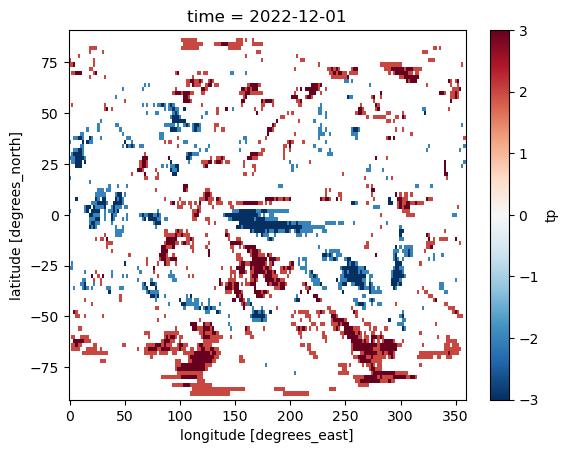

In [8]:
spicat[-1].plot()